In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import joblib

In [29]:
# ============================================================
# PASO 1. CARGA DEL DATASET (desde GitHub)
# ============================================================
print("Cargando dataset propio de hongos...")

url = 'https://raw.githubusercontent.com/roygro/-clasificacion-hongos-arbol-decision/refs/heads/main/hongos_dataset_propio.csv'
df = pd.read_csv(url)

print(f"Dataset cargado:")
print(f"   - Registros: {df.shape[0]}")
print(f"   - Variables: {df.shape[1]} (18 predictoras + 1 objetivo)")
print(f"   - Clases: {df['clase'].unique()}")
print(f"\nPrimeras filas:")
print(df.head())

Cargando dataset propio de hongos...
Dataset cargado:
   - Registros: 1800
   - Variables: 19 (18 predictoras + 1 objetivo)
   - Clases: <StringArray>
['venenoso', 'comestible']
Length: 2, dtype: str

Primeras filas:
      clase     olor color_sombrero forma_sombrero superficie_sombrero  \
0  venenoso  picante         canela        hundido             fibrosa   
1  venenoso   fétido           gris        campana            estriada   
2  venenoso   fétido         canela        campana            escamosa   
3  venenoso  pescado       amarillo          plano             fibrosa   
4  venenoso  pescado         marrón         nudoso            estriada   

  color_laminas tamano_laminas forma_tallo color_tallo tipo_anillo  \
0        morado        angosta   agrandada        rosa      grande   
1        marrón        angosta   agrandada        gris     ninguno   
2          gris          ancha   agrandada      canela     ninguno   
3          rojo          ancha   agrandada      blanco    

In [30]:
# ============================================================
# PASO 2. CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================
print("\nCodificando variables categóricas...")

# Columnas numéricas: se dejan tal cual (no se codifican)
columnas_numericas = ['diametro_sombrero_cm', 'altura_tallo_cm']
# Columnas categóricas: se codifican con LabelEncoder
columnas_categoricas = [c for c in df.columns if c not in columnas_numericas]

df_encoded = df.copy()
encoders = {}
for columna in columnas_categoricas:
    le = LabelEncoder()
    df_encoded[columna] = le.fit_transform(df_encoded[columna])
    encoders[columna] = le

print("Codificación completada. Ejemplo (primeras filas ya codificadas):")
print(df_encoded.head())


Codificando variables categóricas...
Codificación completada. Ejemplo (primeras filas ya codificadas):
   clase  olor  color_sombrero  forma_sombrero  superficie_sombrero  \
0      1     7               2               3                    2   
1      1     3               3               0                    1   
2      1     3               2               0                    0   
3      1     6               0               5                    2   
4      1     6               4               4                    1   

   color_laminas  tamano_laminas  forma_tallo  color_tallo  tipo_anillo  \
0              3               1            0            4            2   
1              2               1            0            2            3   
2              1               0            0            1            3   
3              5               0            0            0            0   
4              7               0            1            2            3   

   numero_anillos 

In [31]:
# ============================================================
# PASO 3. DIVISIÓN EN ENTRENAMIENTO Y PRUEBA
# ============================================================
X = df_encoded.drop('clase', axis=1)
y = df_encoded['clase']  # 0 = comestible, 1 = venenoso (según LabelEncoder alfabético)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nPartición de datos:")
print(f"   - Entrenamiento: {len(X_train)} registros")
print(f"   - Prueba: {len(X_test)} registros")


Partición de datos:
   - Entrenamiento: 1260 registros
   - Prueba: 540 registros


In [32]:
# ============================================================
# PASO 4. ENTRENAMIENTO DEL MODELO
# ============================================================
print("\nEntrenando Árbol de Decisión...")

arbol = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=42,
    min_samples_split=10,
    min_samples_leaf=5
)

arbol.fit(X_train, y_train)
print("Entrenamiento completado")

# ============================================================
# GUARDAR MODELO Y ENCODERS
# ============================================================
print("\nGuardando modelo y encoders...")

# Guardar el árbol de decisión
joblib.dump(arbol, 'modelo_hongos.joblib')

# Guardar los encoders para poder decodificar después
joblib.dump(encoders, 'encoders_hongos.joblib')

# Guardar los nombres de las columnas (opcional pero útil)
joblib.dump(X.columns.tolist(), 'columnas_modelo.joblib')

print("Modelo guardado correctamente en:")
print("   - modelo_hongos.joblib")
print("   - encoders_hongos.joblib")
print("   - columnas_modelo.joblib")


Entrenando Árbol de Decisión...
Entrenamiento completado

Guardando modelo y encoders...
Modelo guardado correctamente en:
   - modelo_hongos.joblib
   - encoders_hongos.joblib
   - columnas_modelo.joblib


In [34]:
# ============================================================
# PASO 5. EVALUACIÓN DEL MODELO
# ============================================================
y_pred = arbol.predict(X_test)
precision = accuracy_score(y_test, y_pred)

nombres_clases = list(encoders['clase'].classes_)  # ['comestible', 'venenoso']

print("\n" + "="*50)
print("RESULTADOS")
print("="*50)
print(f"Precisión (Accuracy): {precision:.4f} ({precision*100:.2f}%)")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=nombres_clases))


RESULTADOS
Precisión (Accuracy): 0.7185 (71.85%)

Reporte de clasificación:
              precision    recall  f1-score   support

  comestible       0.76      0.59      0.66       252
    venenoso       0.70      0.83      0.76       288

    accuracy                           0.72       540
   macro avg       0.73      0.71      0.71       540
weighted avg       0.72      0.72      0.71       540



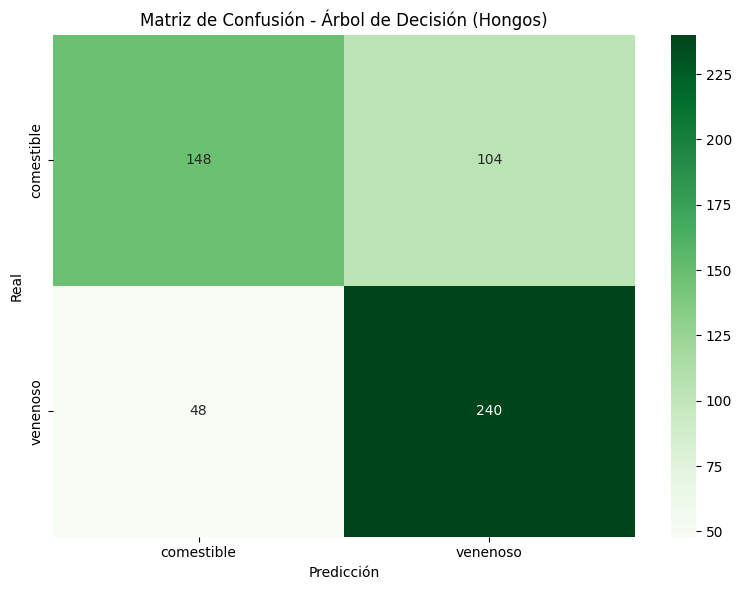


Imagen guardada: matriz_confusion_hongos.png


In [35]:
# ============================================================
# PASO 6. IMAGEN 1 - MATRIZ DE CONFUSIÓN
# ============================================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Árbol de Decisión (Hongos)')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.savefig('matriz_confusion_hongos.png', dpi=300)
plt.show()
print("\nImagen guardada: matriz_confusion_hongos.png")

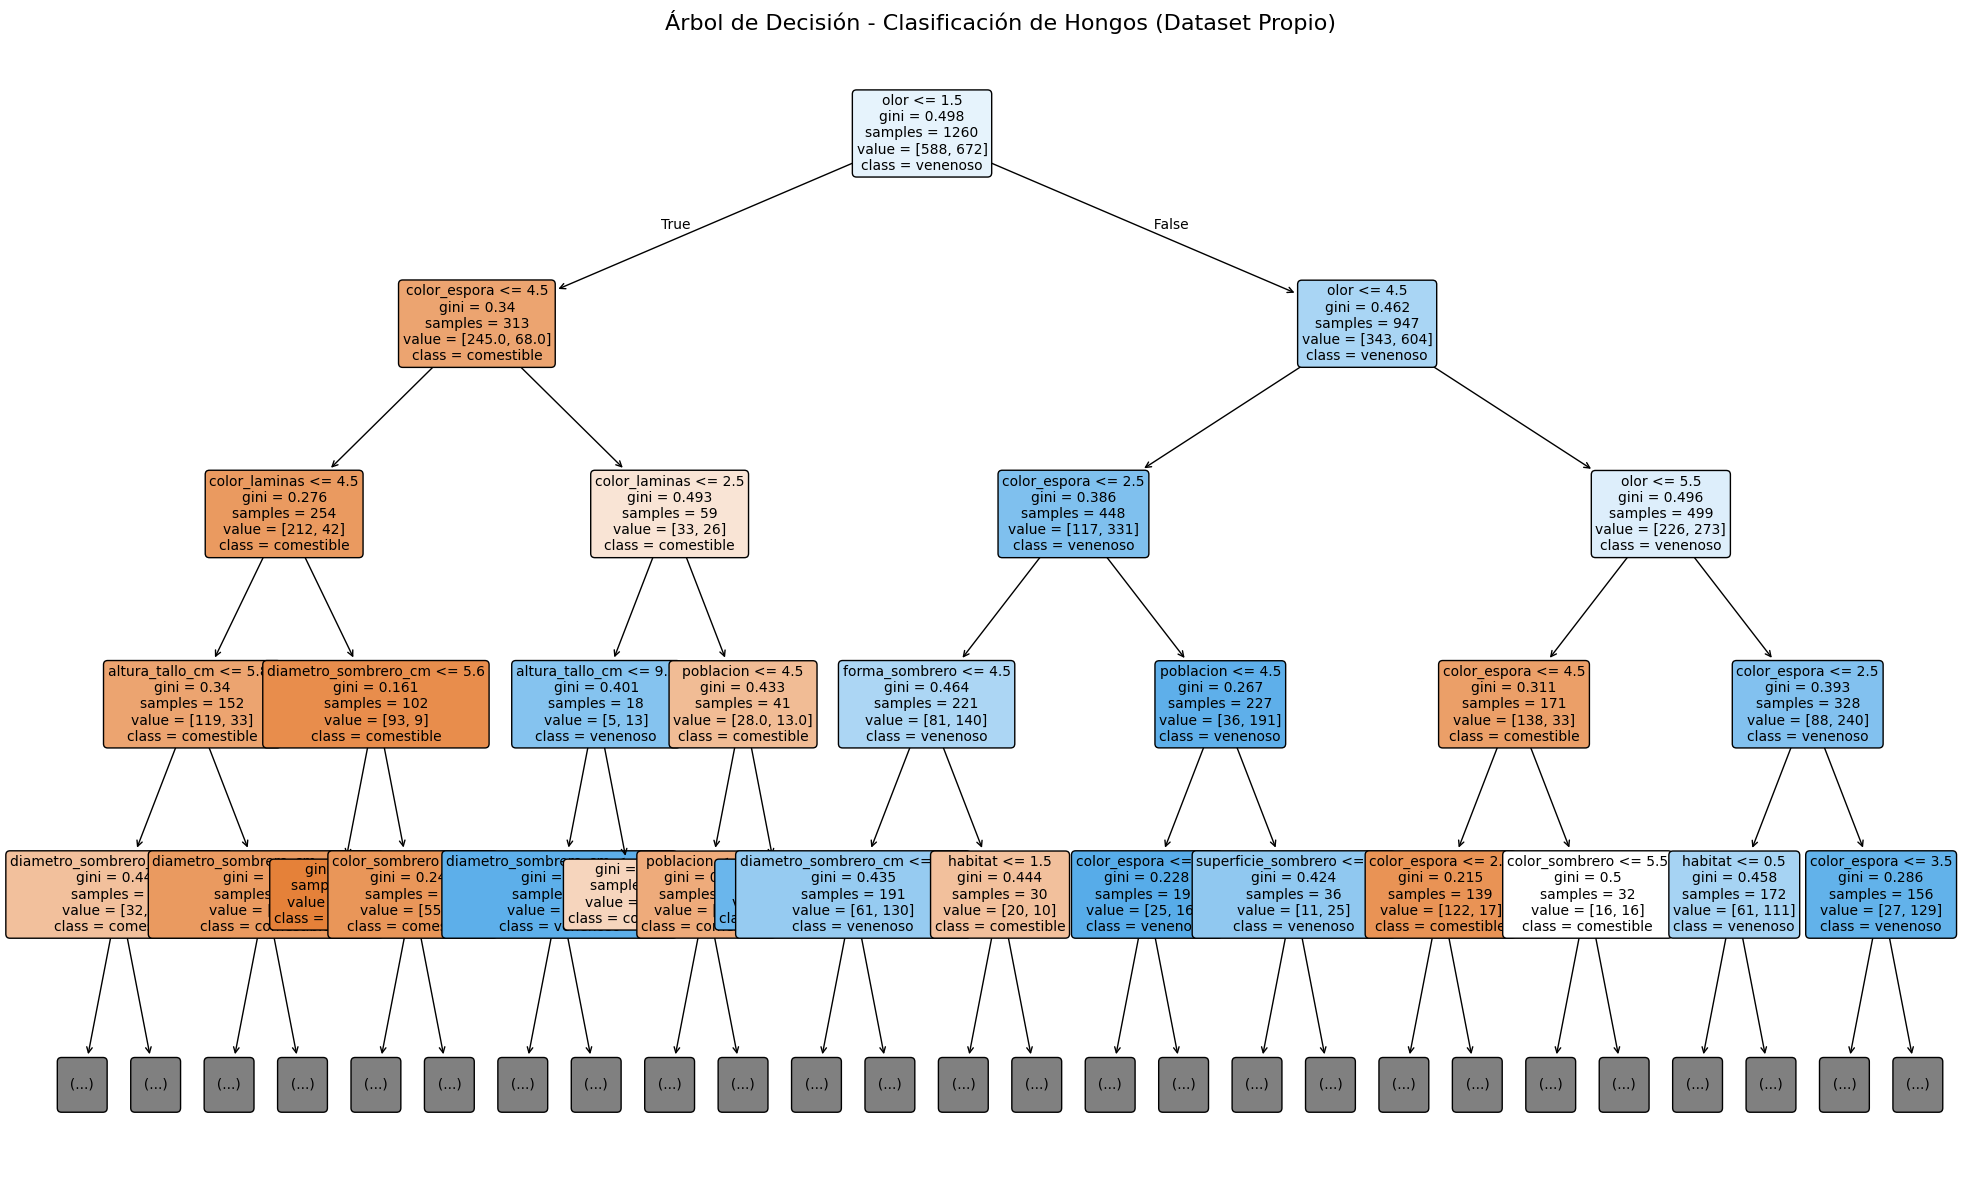

Imagen guardada: arbol_hongos.png


In [36]:
# ============================================================
# PASO 7. IMAGEN 2 - VISUALIZACIÓN DEL ÁRBOL
# ============================================================
plt.figure(figsize=(20, 12))
plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=nombres_clases,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=4
)
plt.title('Árbol de Decisión - Clasificación de Hongos (Dataset Propio)', fontsize=16)
plt.tight_layout()
plt.savefig('arbol_hongos.png', dpi=300, bbox_inches='tight')
plt.show()
print("Imagen guardada: arbol_hongos.png")


TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES
      Característica  Importancia
                olor     0.665758
        color_espora     0.149366
diametro_sombrero_cm     0.052657
      forma_sombrero     0.025112
       color_laminas     0.024628
           poblacion     0.023797
             habitat     0.022045
      color_sombrero     0.015715
     altura_tallo_cm     0.013382
 superficie_sombrero     0.007539


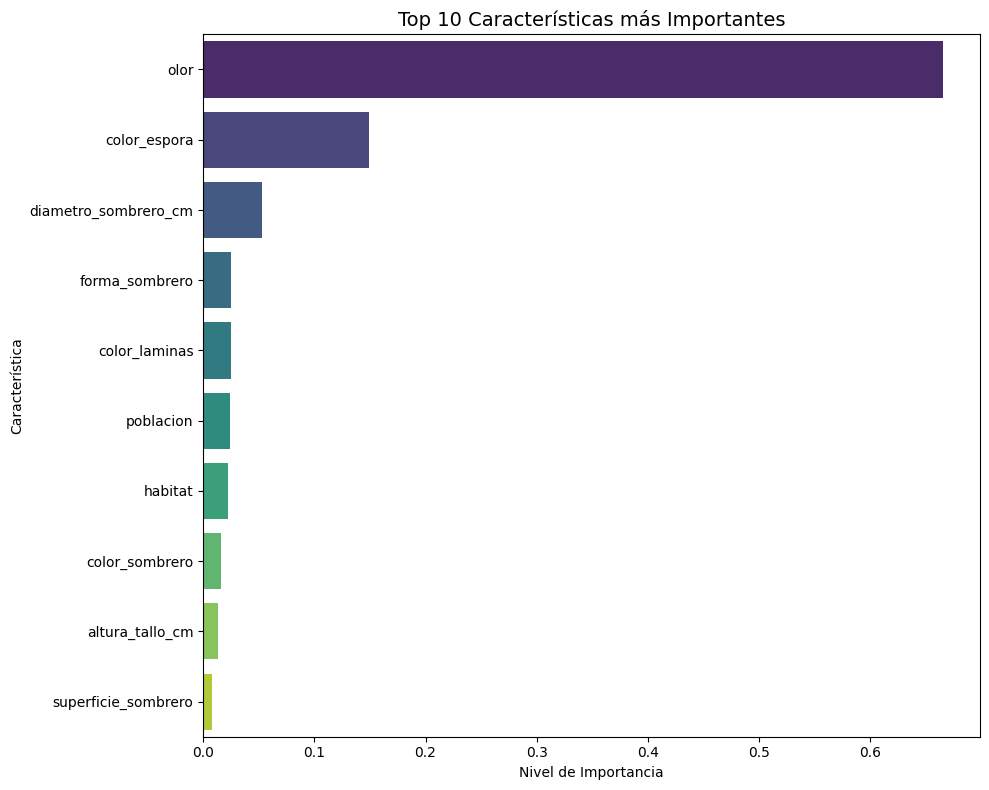

Imagen guardada: importancias_hongos.png


In [37]:
# ============================================================
# PASO 8. IMAGEN 3 - IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================
importancias = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': arbol.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\n" + "="*50)
print("TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES")
print("="*50)
print(importancias.head(10).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importancias.head(10),
    y='Característica',
    x='Importancia',
    hue='Característica',   # <--- Agregado para evitar FutureWarning
    palette='viridis',
    legend=False            # <--- Desactiva la leyenda
)
plt.title('Top 10 Características más Importantes', fontsize=14)
plt.xlabel('Nivel de Importancia')
plt.tight_layout()
plt.savefig('importancias_hongos.png', dpi=300)
plt.show()

print("Imagen guardada: importancias_hongos.png")

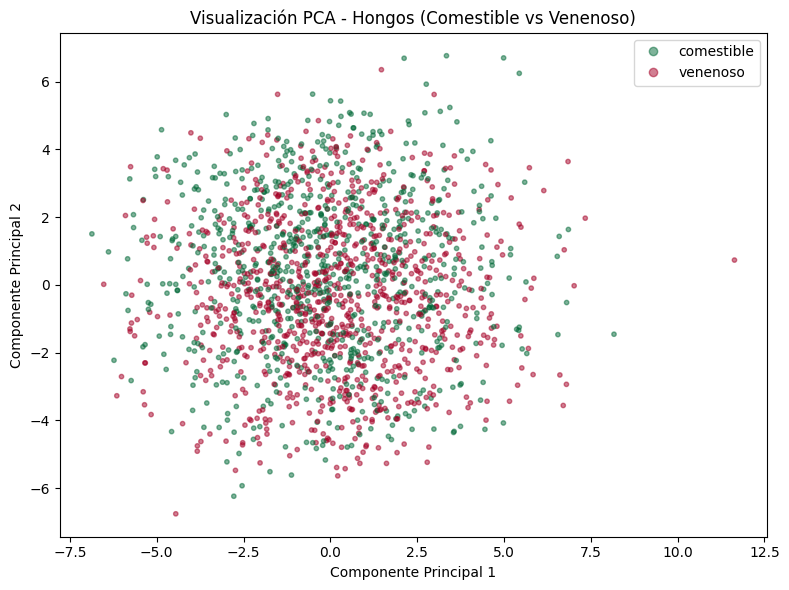

Imagen guardada: pca_hongos.png


In [38]:
# ============================================================
# PASO 9. IMAGEN 4 - PROCESAMIENTO PCA (para Actividad 2)
# ============================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdYlGn_r', alpha=0.5, s=10)
plt.title('Visualización PCA - Hongos (Comestible vs Venenoso)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(handles=scatter.legend_elements()[0], labels=nombres_clases)
plt.tight_layout()
plt.savefig('pca_hongos.png', dpi=300)
plt.show()
print("Imagen guardada: pca_hongos.png")

In [39]:
# ============================================================
# PASO 10. EJEMPLO DE CLASIFICACIÓN INDIVIDUAL
# ============================================================
print("\n" + "="*50)
print("EJEMPLO DE CLASIFICACIÓN DE UN HONGO")
print("="*50)

ejemplo_idx = 0
ejemplo = X_test.iloc[[ejemplo_idx]]
prediccion = arbol.predict(ejemplo)
probabilidad = arbol.predict_proba(ejemplo)

resultado = nombres_clases[prediccion[0]]
print(f"Resultado: {resultado}")
for i, nombre_clase in enumerate(nombres_clases):
    print(f"   Probabilidad {nombre_clase}: {probabilidad[0][i]:.2%}")


EJEMPLO DE CLASIFICACIÓN DE UN HONGO
Resultado: comestible
   Probabilidad comestible: 80.65%
   Probabilidad venenoso: 19.35%


In [40]:
# ============================================================
# PASO 11. ESTADÍSTICAS FINALES
# ============================================================
print("\n" + "="*50)
print("ESTADÍSTICAS FINALES DEL MODELO")
print("="*50)
print(f"Total registros: {len(df)}")
print(f"Total variables: {len(df.columns)}")
print(f"Distribución de clases:\n{df['clase'].value_counts()}")
print(f"\nProfundidad del árbol: {arbol.tree_.max_depth}")
print(f"Número de nodos: {arbol.tree_.node_count}")
print(f"Número de hojas: {arbol.tree_.n_leaves}")


ESTADÍSTICAS FINALES DEL MODELO
Total registros: 1800
Total variables: 19
Distribución de clases:
clase
venenoso      960
comestible    840
Name: count, dtype: int64

Profundidad del árbol: 5
Número de nodos: 57
Número de hojas: 29
